In [1]:
import sklearn
import pandas as pd
print("scikit-learn:", sklearn.__version__)  # 1.8.x
print("pandas:", pd.__version__)             # 3.x.x

scikit-learn: 1.8.0
pandas: 3.0.3


In [2]:
import sklearn
import matplotlib.pyplot as plt
print("sklearn:", sklearn.__version__)

sklearn: 1.8.0


In [3]:
bream_length = [25.4, 26.3, 26.5, 29.0, 29.0, 29.7, 29.7, 30.0, 30.0, 30.7,
                31.0, 31.0, 31.5, 32.0, 32.0, 32.0, 33.0, 33.0, 33.5, 33.5,
                34.0, 34.0, 34.5, 35.0, 35.0, 35.0, 35.0, 36.0, 36.0, 37.0,
                38.5, 38.5, 39.5, 41.0, 41.0]
bream_weight = [242.0, 290.0, 340.0, 363.0, 430.0, 450.0, 500.0, 390.0, 450.0,
                500.0, 475.0, 500.0, 500.0, 340.0, 600.0, 600.0, 700.0, 700.0,
                610.0, 650.0, 575.0, 685.0, 620.0, 680.0, 700.0, 725.0, 720.0,
                714.0, 850.0, 1000.0, 920.0, 955.0, 925.0, 975.0, 950.0]

smelt_length = [9.8, 10.5, 10.6, 11.0, 11.2, 11.3, 11.8, 11.8, 12.0, 12.2,
                12.4, 13.0, 14.3, 15.0]
smelt_weight = [6.7, 7.5, 7.0, 9.7, 9.8, 8.7, 10.0, 9.9, 9.8, 12.2,
                13.4, 12.2, 19.7, 19.9]

print(f"도미: {len(bream_length)}마리, 빙어: {len(smelt_length)}마리")

도미: 35마리, 빙어: 14마리


In [4]:
fish_length = bream_length + smelt_length
fish_weight = bream_weight + smelt_weight

fish_data = [[l, w] for l, w in zip(fish_length, fish_weight)]
fish_target = [1] * 35 + [0] * 14   # 도미=1, 빙어=0

print(f"전체: {len(fish_data)}마리")
print(f"첫 샘플: {fish_data[0]}, 레이블: {fish_target[0]}")

전체: 49마리
첫 샘플: [25.4, 242.0], 레이블: 1


c:\Users\금정산2-PC11\Study_List\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 47924 (\N{HANGUL SYLLABLE MU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\금정산2-PC11\Study_List\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44172 (\N{HANGUL SYLLABLE GE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\금정산2-PC11\Study_List\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\금정산2-PC11\Study_List\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 48120 (\N{HANGUL SYLLABLE MI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\금정산2-PC11\Study_List\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 50752 (\N{HANGUL SYLLABLE WA}) missing from fon

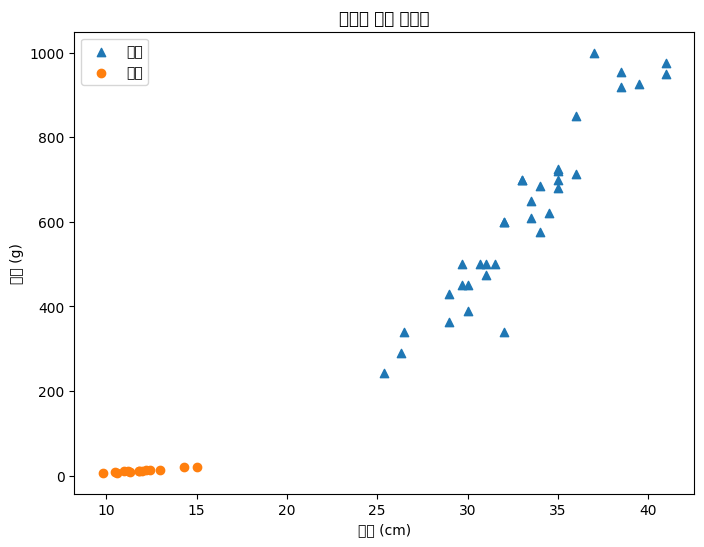

In [5]:
plt.figure(figsize=(8, 6))
plt.scatter(bream_length, bream_weight, marker='^', label='도미')
plt.scatter(smelt_length, smelt_weight, marker='o', label='빙어')
plt.xlabel('길이 (cm)')
plt.ylabel('무게 (g)')
plt.title('도미와 빙어 산점도')
plt.legend()
plt.show()

In [6]:
from sklearn.neighbors import KNeighborsClassifier

kn = KNeighborsClassifier()   # 기본 k=5
kn.fit(fish_data, fish_target)
print("학습 완료!")

학습 완료!


In [7]:
prediction = kn.predict([[30, 600]])
print("예측:", prediction)           # [1] → 도미
print("정확도:", kn.score(fish_data, fish_target))  # 1.0

예측: [1]
정확도: 1.0


In [8]:
print("학습 데이터:", len(fish_data), "개")
print("평가 데이터:", len(fish_data), "개  ← 같은 데이터!")
print("→ 답지 보고 채점한 것. 다음 실습에서 해결한다.")

학습 데이터: 49 개
평가 데이터: 49 개  ← 같은 데이터!
→ 답지 보고 채점한 것. 다음 실습에서 해결한다.


In [9]:
from sklearn.model_selection import train_test_split

train_input, test_input, train_target, test_target = train_test_split(
    fish_data, fish_target, random_state=42
)

print(f"훈련: {len(train_input)}개")   # 36
print(f"테스트: {len(test_input)}개")  # 13

훈련: 36개
테스트: 13개


In [10]:
from sklearn.neighbors import KNeighborsClassifier

kn = KNeighborsClassifier()
kn.fit(train_input, train_target)    # 훈련 데이터만 사용

train_score = kn.score(train_input, train_target)
test_score = kn.score(test_input, test_target)

print(f"훈련 정확도: {train_score:.4f}")
print(f"테스트 정확도: {test_score:.4f}")

훈련 정확도: 1.0000
테스트 정확도: 1.0000


In [11]:
print(f"훈련 — 도미: {train_target.count(1)}, 빙어: {train_target.count(0)}")
print(f"테스트 — 도미: {test_target.count(1)}, 빙어: {test_target.count(0)}")

훈련 — 도미: 25, 빙어: 11
테스트 — 도미: 10, 빙어: 3


In [12]:
train_i, test_i, train_t, test_t = train_test_split(
    fish_data, fish_target,
    random_state=42,
    stratify=fish_target   # 도미:빙어 비율 유지
)

FileNotFoundError: [Errno 2] No such file or directory: 'titanic.csv'